In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import gaussian_filter1d
from matplotlib import ticker as mtick
import utils.constants as consts
plt.style.use(["seaborn-v0_8-colorblind"])
plt.rcParams.update({
    "font.size":11})

warnings.filterwarnings("ignore", message=".*Attempting to set identical low and high xlims.*")
unitnames = ['$\\Gamma_i$ [$m^{-2} s^{-1}$]', '$n$ $[m^{-3}]$',
         'E $[Vm^{-1}]$', '$T_e$ $[eV]$', '$T_i$ $[eV]$']
names = ['$\\Gamma_i$', '$n$', 
          'E', '$T_e$', '$T_i$']
dnames = ['$\\Gamma_i$', '$n$', 'E', '$T_e$', '$T_i$', 
          '$dn$/dx', 'd$T_e$', 'd$T_i$', 'd$\\Gamma_i$']

cur_dir = os.path.dirname(os.path.abspath('__file__'))
base_path = os.path.join(os.path.dirname(cur_dir), 'data/')
problem = "rf"
case = "pic"
PATH_TO_DATA = os.path.join(base_path, problem, case, "ml_data", "ccp_dataset.npz")
# physical constants
p = consts.PhysicalConstants()

# other constants

o = consts.OtherConstants()

snapshot = 65

In [2]:
npz_data = np.load(PATH_TO_DATA) 
load_data = npz_data["profiles"]

fluxi = load_data[..., 1]

# spatial inputs
ne = load_data[..., 2]
ni = load_data[..., 3]
phi = load_data[..., 4]
E = load_data[..., 5]
Te = load_data[..., 6]
Ti = load_data[..., 7]
profile_i = np.stack([fluxi, ni, E, Te, Ti])

pres = load_data[..., 8]
freq = load_data[..., 9]

N, L = ni.shape
x0, x1 = 0.0, 0.05
x_phys = np.linspace(x0, x1, L)
mid = L // 2

# bulk/sheath masks from split_indices
split_indices = np.load(os.path.join(base_path, problem, case, "split_indices.npy")) 
c = L // 2 
cols = np.arange(L)
sR = c + split_indices
sL = (c - 1) - split_indices
is_sheath = (cols[None, :] >= sR[:, None]) | (cols[None, :] <= sL[:, None])
is_bulk = ~is_sheath

ba, bb = 258, 358
bulk_range = np.arange(ba, bb)
plotting_range = np.arange(0, 100)
x_cm = x_phys[bulk_range] * 100.0
plotting_cm = x_phys[plotting_range] * 100.0
nplots = 5
ncols = 3
nrows = int(np.ceil(nplots/ncols))

In [3]:
def band_stats(y2d):
    y2d = np.asarray(y2d, float)
    y_min = np.nanmin(y2d, axis=0)
    y_max = np.nanmax(y2d, axis=0)
    p05 = np.nanpercentile(y2d, 5, axis=0)
    p25 = np.nanpercentile(y2d, 25, axis=0)
    p50 = np.nanpercentile(y2d, 50, axis=0)
    p75 = np.nanpercentile(y2d, 75, axis=0)
    p95 = np.nanpercentile(y2d, 95, axis=0)
    return y_min, y_max, p05, p25, p50, p75, p95

def select_yscale(y2d):
    y = y2d[np.isfinite(y2d)]
    if y.size == 0:
        return "linear", None
    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    if ymin == ymax:
        return "linear", None

    has_pos = np.any(y > 0.0)
    has_neg = np.any(y < 0.0)

    if has_pos and has_neg:
        p50 = np.nanpercentile(np.abs(y), 50)
        p95 = np.nanpercentile(np.abs(y), 95)
        if p50 > 0.0 and (p95 / p50) > 1e3:
            linthresh = np.nanpercentile(np.abs(y), 5)
            linthresh = float(linthresh) if linthresh > 0.0 else float(p50)
            return "symlog", {"linthresh": linthresh}
        return "linear", None

    if has_pos and not has_neg:
        p05 = np.nanpercentile(y, 5)
        p95 = np.nanpercentile(y, 95)
        if p05 > 0.0 and (p95 / p05) > 1e3:
            return "log", None
        return "linear", None

    return "linear", None

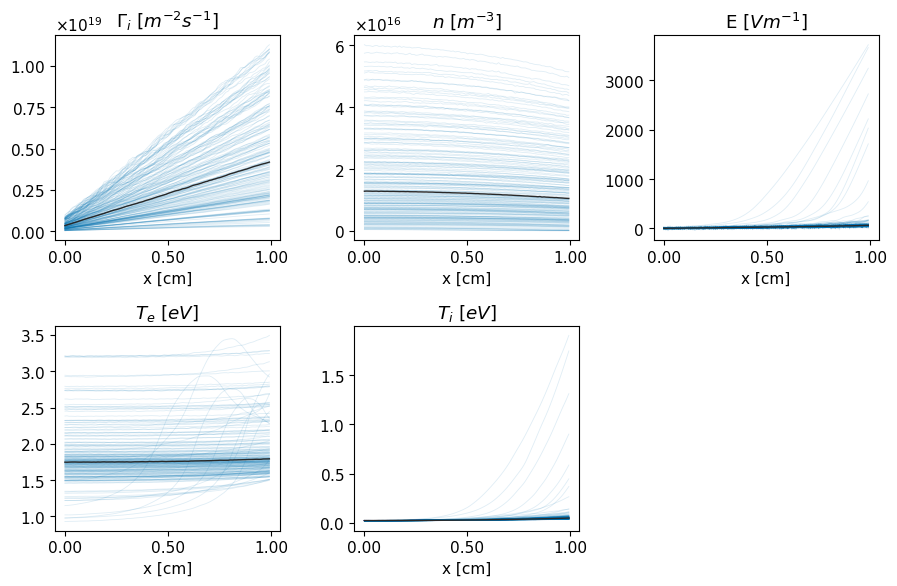

In [4]:
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(2.7 * ncols + 1.0, 3.0 * nrows),
    tight_layout=True
)
axes = np.atleast_1d(axes).ravel()

for ax, arr, label in zip(axes, profile_i, unitnames):
    y = arr[:, ba:bb]  # (N_snap, Lx)

    q10, q25, q50, q75, q90 = np.percentile(y, [5, 25, 50, 75, 95], axis=0)

    for i in range(y.shape[0]):
        ax.plot(plotting_cm, y[i, :], color="#0072B2", alpha=0.125, linewidth=0.6)

    # median curve
    ax.plot(plotting_cm, q50, color="#282828FF", linewidth=1, label="median")

    ax.set_title(label)
    ax.set_xlabel("x [cm]")
    # ax.grid(True, alpha=0.25)

    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))
    ax.yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))

for j in range(len(unitnames), len(axes)):
    axes[j].axis("off")

# optional legend
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles[:3], labels[:3], loc="upper center", ncol=3, frameon=False)
fig.savefig(f"all_raw_profiles.svg")

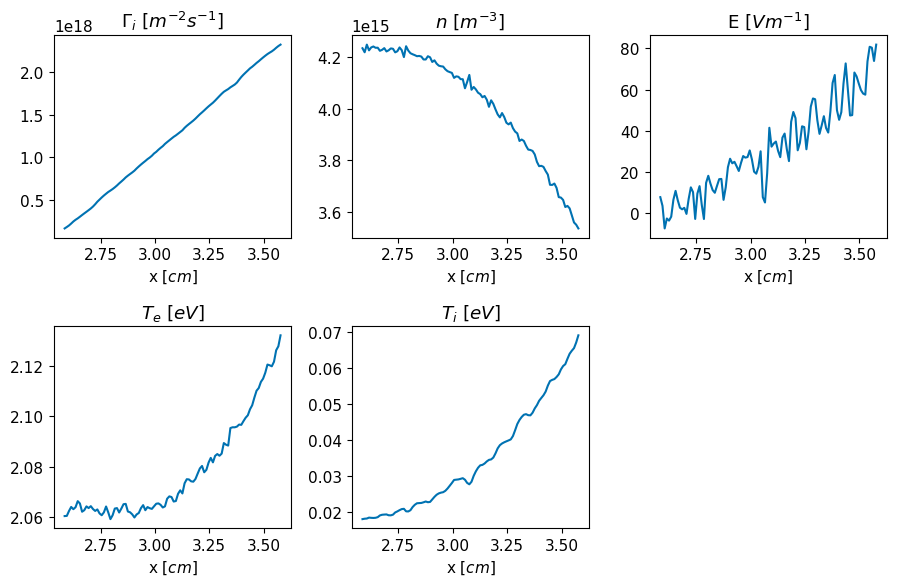

In [5]:
fig, axes = plt.subplots(nrows, ncols, figsize=(2.7*ncols+1, 3*nrows), tight_layout=True)
axes = np.atleast_1d(axes).ravel()
for ax, arr, label in zip(axes, profile_i, unitnames):
    ax.plot(x_cm, arr[snapshot][ba:bb], lw=1.5)
    ax.set_title(label)
    ax.set_xlabel('x [$cm$]')
for j in range(len(unitnames), len(axes)):
    axes[j].axis('off')
# fig.suptitle(f"Frequency: {freq[snapshot, 0]}MHz, Pressure: {pres[snapshot, 0]}mTorr")
plt.gca().xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
fig.savefig(f"Xraw_profiles_P{pres[snapshot, 0]}_F{freq[snapshot, 0]}.svg")

In [6]:
def row_mean_masked(A, M): 
    out = np.empty((A.shape[0],), dtype=A.dtype) 
    for i in range(A.shape[0]): 
        a = A[i, M[i]] 
        out[i] = np.mean(a) if a.size else np.mean(A[i]) 
    return out


n_ref = row_mean_masked(ni, is_bulk)[:, None]
Te_ref = row_mean_masked(Te, is_bulk)[:, None]

Lp = 0.5 * 0.05
Tg = 300 # [K]

n_ref_global = float(np.mean(n_ref))
Te_ref_global = float(np.mean(Te_ref))
L0 = float(np.mean(0.05))

# physical scales
E0 = Te_ref_global / (Lp) # + o.delta)
cs = float(np.sqrt(p.q * Te_ref_global / p.m_i))
G0 = n_ref_global * cs

# dimensionless variables
ni_t = ni / (n_ref_global + o.delta)
ne_t = ne / (n_ref_global + o.delta)
Te_t = Te / (Te_ref_global + o.delta)
Ti_t = Ti / (Tg / p.K_eV)
E_t = E / (E0 + o.delta)
fluxi_t = fluxi / (G0 + o.delta)

Text(0.5, 0.98, 'Frequency: 27.12MHz, Pressure: 4.0mTorr')

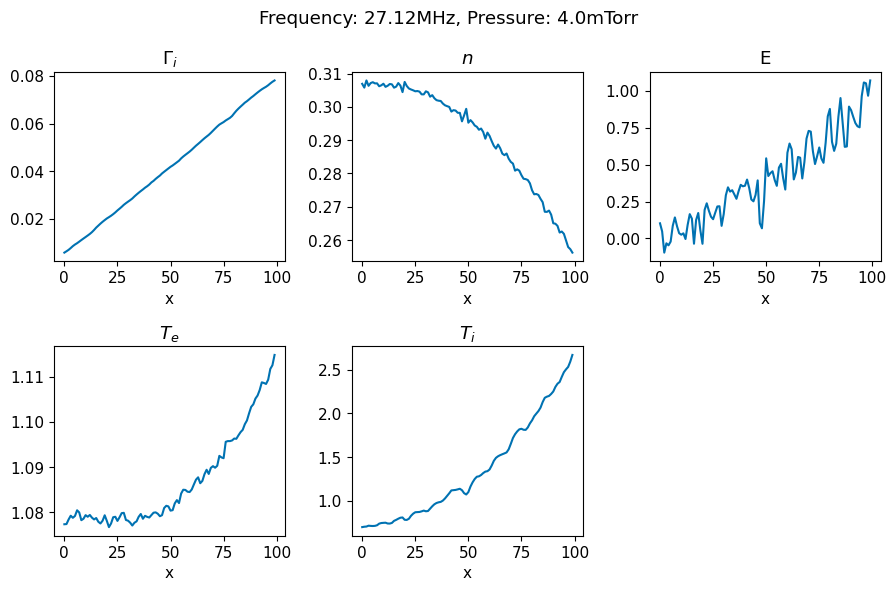

In [7]:
scaled_profiles = np.stack([fluxi_t, ni_t, E_t, Te_t, Ti_t])
nrows = int(np.ceil(nplots/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(2.7*ncols+1, 3*nrows), tight_layout=True)
axes = np.atleast_1d(axes).ravel()
for ax, arr, label in zip(axes, scaled_profiles, names):
    ax.plot(arr[snapshot][ba:bb], lw=1.5)
    ax.set_title(label)
    ax.set_xlabel('x')
for j in range(len(names), len(axes)):
    axes[j].axis('off')
fig.suptitle(f"Frequency: {freq[snapshot, 0]}MHz, Pressure: {pres[snapshot, 0]}mTorr")

In [8]:
def robust_sigma_1d(y, order=2):
    if order == 1:
        d = np.diff(y)
        return np.median(np.abs(d)) / (0.6745 * np.sqrt(2.0))
    elif order == 2:
        d2 = y[2:] - 2*y[1:-1] + y[:-2]
        return np.median(np.abs(d2)) / (0.6745 * np.sqrt(6.0))

def per_sample_sigma_masked(Yt, mask, order=2):
    sig = np.empty((N,), dtype=float)
    for i in range(N):
        idx = np.flatnonzero(mask[i])
        if idx.size < 6:
            sig[i] = robust_sigma_1d(Yt[i], order=order)
        else:
            sig[i] = robust_sigma_1d(Yt[i, idx], order=order)
    return sig[:, None]# (N,1)

# noise levels (dimensionless)
sig_ni_bulk = per_sample_sigma_masked(ni_t, is_bulk, order=1)
sig_ne_bulk = per_sample_sigma_masked(ne_t, is_bulk, order=1)
sig_Te_bulk = per_sample_sigma_masked(Te_t, is_bulk, order=1)
sig_Ti_bulk = per_sample_sigma_masked(Ti_t, is_bulk, order=1)
sig_E_bulk = per_sample_sigma_masked(E_t, is_bulk, order=1)
sig_flux_bulk = per_sample_sigma_masked(fluxi_t, is_bulk, order=1)

def _fit_segment(xseg, yseg, s_val, kval):
    n = len(xseg)
    kval = min(kval, max(n-1, 1))
    if n >= (kval + 2):
        spl = UnivariateSpline(xseg, yseg, s=s_val, k=kval)
        yhat = spl(xseg)
        dy = gaussian_filter1d(spl.derivative(1)(xseg), sigma=1)
    else:
        # too short: copy and smooth finite differences
        yhat = yseg.copy()
        if n >= 3:
            dy_raw = np.gradient(yseg, xseg, edge_order=2)
        elif n == 2:
            dy_raw = np.full_like(yseg, (yseg[1]-yseg[0])/(xseg[1]-xseg[0]))
        else:
            dy_raw = np.zeros_like(yseg)
        dy = gaussian_filter1d(dy_raw, sigma=1) if n >= 3 else dy_raw
    return yhat, dy

def smooth_three_region(Yt, sigma_bulk, k=3, gamma=1):
    Yhat = np.empty_like(Yt)
    dYdx = np.empty_like(Yt)
    x_phys = np.linspace(0.0, 0.05, L)
    for i in range(N):
        l = int(sL[i]); r = int(sR[i])
        # segments
        xR, yR = x_phys[r:], Yt[i, r:]
        xL, yL = x_phys[:l], Yt[i, :l]
        xB, yB = x_phys[l:r], Yt[i, l:r]

        # smoothing strengths (proportional to region length and noise^2)
        sB_val = gamma * max(len(yB), 1) * float(sigma_bulk[i, 0]**2)

        # degrees
        kL = kR = kB = k

        # fit
        yBhat, dyB = _fit_segment(xB, yB, sB_val, kB)
        Yhat[i, l:r] = yBhat
        dYdx[i, l:r] = dyB

    return Yhat, dYdx

gamma = 1.0

ni_t_hat, dni_t_dx_phys = smooth_three_region(ni_t, sig_ni_bulk, k=3, gamma=1)
ne_t_hat, dne_t_dx_phys = smooth_three_region(ne_t, sig_ne_bulk, k=3, gamma=1)
Te_t_hat, dTe_t_dx_phys = smooth_three_region(Te_t, sig_Te_bulk, k=3, gamma=1)
Ti_t_hat, dTi_t_dx_phys = smooth_three_region(Ti_t, sig_Ti_bulk, k=3, gamma=1)
E_t_hat, _ = smooth_three_region(E_t, sig_E_bulk, k=3, gamma=2)
fluxi_t_hat, dfluxi_t_phys = smooth_three_region(fluxi_t, sig_flux_bulk, k=3, gamma=1)

dni_t_dx = dni_t_dx_phys * L0
dTe_t_dx = dTe_t_dx_phys * L0
dTi_t_dx = dTi_t_dx_phys * L0
dfluxi_t_dx = dfluxi_t_phys * L0

smooth_profiles = np.stack([fluxi_t_hat, ni_t_hat, E_t_hat, Te_t_hat, Ti_t_hat, 
                            dni_t_dx, dTe_t_dx, dTi_t_dx, dfluxi_t_dx])

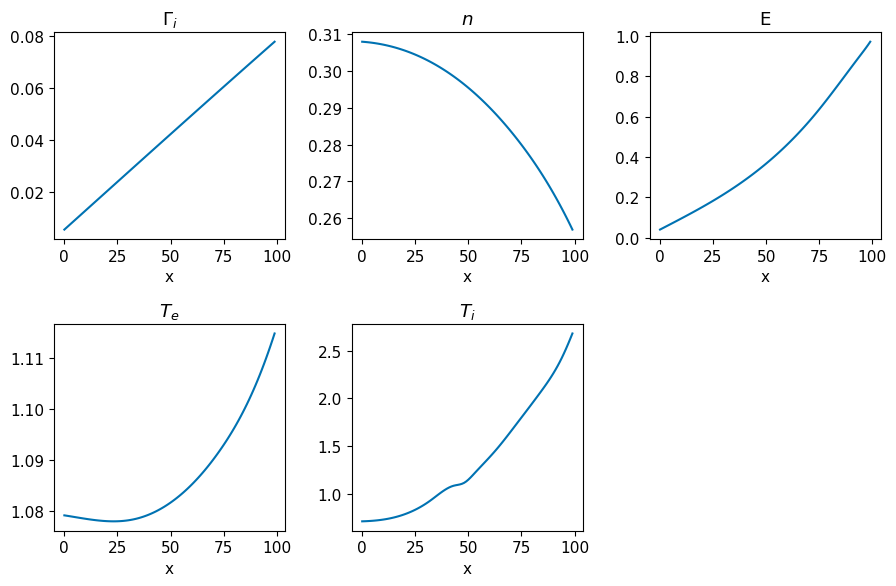

In [9]:
nrows = int(np.ceil(nplots/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(2.7*ncols+1, 3*nrows), tight_layout=True)
axes = np.atleast_1d(axes).ravel()
for ax, arr, label in zip(axes, smooth_profiles, names):
    ax.plot(arr[snapshot][ba:bb], lw=1.5)
    ax.set_title(label)
    ax.set_xlabel('x')
for j in range(len(names), len(axes)):
    axes[j].axis('off')
# fig.suptitle(f"Frequency: {freq[snapshot, 0]}MHZ, Pressure: {pres[snapshot, 0]}mTorr")

fig.savefig(f"nodxsmoothed_profiles_P{pres[snapshot, 0]}_F{freq[snapshot, 0]}.svg")

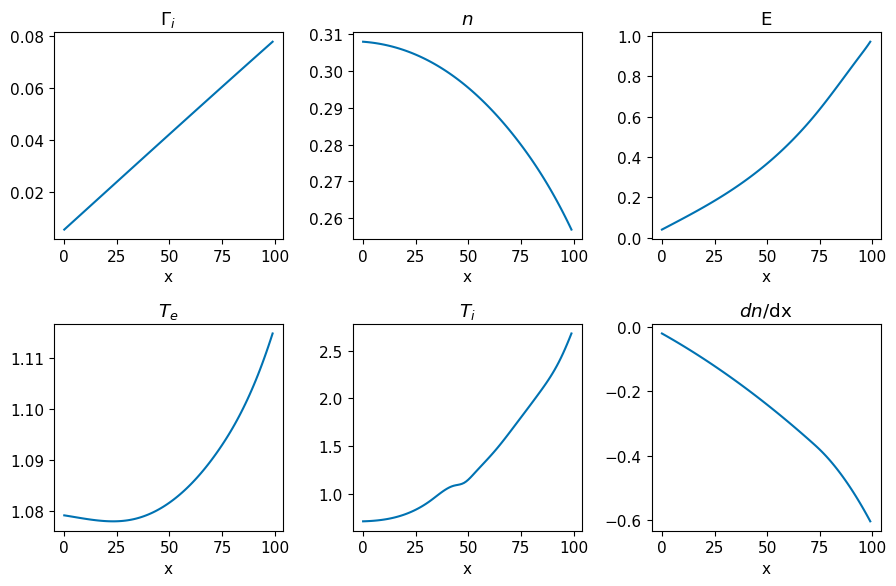

In [10]:
ncols = 3
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(2.7*ncols+1, 3*nrows), tight_layout=True)
axes = np.atleast_1d(axes).ravel()
for ax, arr, label in zip(axes, smooth_profiles, dnames):
    ax.plot(arr[snapshot][ba:bb], lw=1.5)
    ax.set_title(label)
    ax.set_xlabel('x')
for j in range(len(dnames), len(axes)):
    axes[j].axis('off')
# fig.suptitle(f"Frequency: {freq[snapshot, 0]}MHZ, Pressure: {pres[snapshot, 0]}mTorr")

fig.savefig(f"smoothed_profiles_P{pres[snapshot, 0]}_F{freq[snapshot, 0]}.svg")

In [11]:
# normalize pressure and driving frequency 
pres_hat = pres / np.mean(pres[:, 0])
freq_hat = freq / np.mean(freq[:, 0])

bulk_profiles = np.stack([fluxi_t_hat[:, ba:bb], ni_t_hat[:, ba:bb], 
                              dni_t_dx[:, ba:bb], E_t_hat[:, ba:bb], 
                              Te_t_hat[:, ba:bb], dTe_t_dx[:, ba:bb],
                              Ti_t_hat[:, ba:bb], dTi_t_dx[:, ba:bb],
                              dfluxi_t_dx[:, ba:bb],
                              pres_hat[:, ba:bb], freq_hat[:, ba:bb]
                              ], axis=-1)   

# need to order samples by increasing pressure-frequency pairs
idx = np.lexsort((freq_hat[:, ba], pres_hat[:, ba]))
sorted_bulk_profiles = bulk_profiles[idx, :, :]

p_split, f_split = 1.0, 1.0
p_bin = np.digitize(pres_hat[:, ba][idx], [p_split], right=False)
f_bin = np.digitize(freq_hat[:, ba][idx], [f_split], right=False)

In [ ]:
np.savez_compressed(os.path.join(base_path, problem, case, "scaling_consts.npz"), 
                    ni0 = (n_ref_global + o.delta),
                    ne0 = (n_ref_global + o.delta),
                    Te0 = (Te_ref_global + o.delta),
                    Ti0 = (Tg / p.K_eV),
                    E0 = (E0 + o.delta),
                    flux0 = (G0 + o.delta),
                    P0 = np.mean(pres[:, 0]), 
                    F0 = np.mean(freq[:, 0])
                    )

Text(0.5, 1.0, 'Operating-space coverage (raw)')

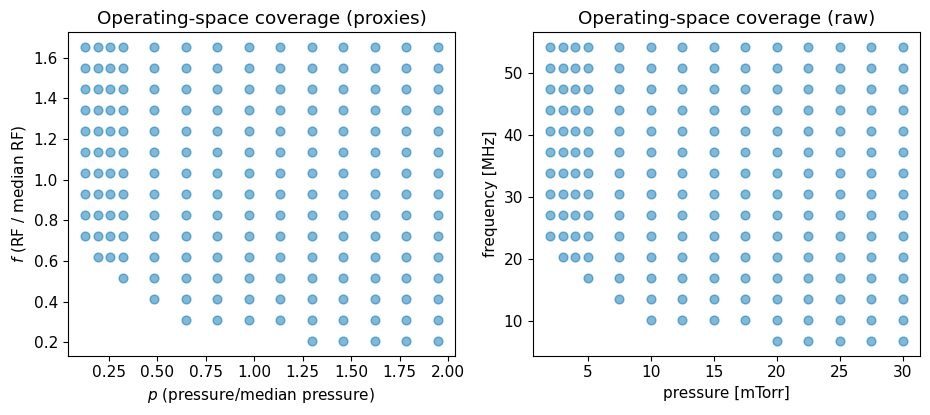

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(pres_hat.reshape(-1, pres_hat.shape[1])[:, 0],
            freq_hat.reshape(-1, freq_hat.shape[1])[:, 0],
            s=40, alpha=0.5)
axes[0].set_xlabel(r"$p$ (pressure/median pressure)")
axes[0].set_ylabel(r"$f$ (RF / median RF)")
axes[0].set_title("Operating-space coverage (proxies)")

axes[1].scatter(pres.reshape(-1, pres_hat.shape[1])[:, 0], 
            freq.reshape(-1, freq_hat.shape[1])[:, 0], 
            s=40, alpha=0.5)
axes[1].set_xlabel("pressure [mTorr]")
axes[1].set_ylabel("frequency [MHz]")
axes[1].set_title("Operating-space coverage (raw)")

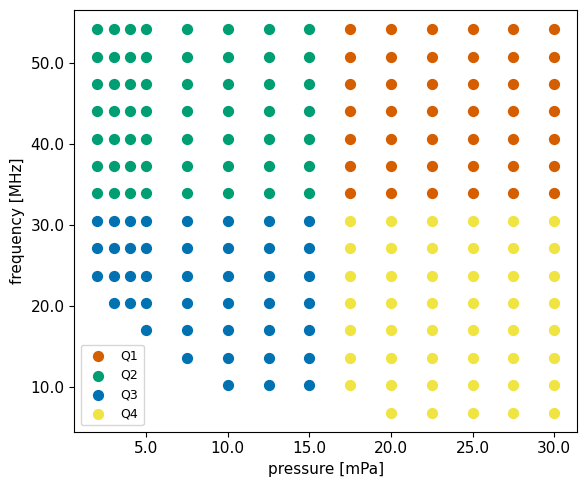

In [13]:
q2_bulk = sorted_bulk_profiles[(p_bin == 0) & (f_bin == 1)]
q1_bulk = sorted_bulk_profiles[(p_bin == 1) & (f_bin == 1)]
q4_bulk = sorted_bulk_profiles[(p_bin == 1) & (f_bin == 0)]
q3_bulk = sorted_bulk_profiles[(p_bin == 0) & (f_bin == 0)]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np.mean(pres[:, 0]) * q1_bulk[:, 0, -2], np.mean(freq[:, 0]) * q1_bulk[:, 0, -1], 
           s=50, label='Q1', c='#D55E00')
ax.scatter(np.mean(pres[:, 0]) * q2_bulk[:, 0, -2], np.mean(freq[:, 0]) * q2_bulk[:, 0, -1], 
           s=50, label='Q2', c='#009E73')
ax.scatter(np.mean(pres[:, 0]) * q3_bulk[:, 0, -2], np.mean(freq[:, 0]) * q3_bulk[:, 0, -1], 
           s=50, label='Q3', c='#0072B2')
ax.scatter(np.mean(pres[:, 0]) * q4_bulk[:, 0, -2], np.mean(freq[:, 0]) * q4_bulk[:, 0, -1], 
           s=50, label='Q4', c='#F0E442')
ax.legend(fontsize=9)

ax.set_xlabel("pressure [mPa]")
ax.set_ylabel("frequency [MHz]")
ax.xaxis.set_major_formatter('{x:.1f}')
ax.yaxis.set_major_formatter('{x:.1f}')
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(base_path, "pf_sample_sweep.svg"))

In [ ]:
np.savez_compressed(os.path.join(base_path, problem, case, "ml_data", "mean_bulk_ccp_dataset.npz"), 
                    profiles=sorted_bulk_profiles)